In [1]:
from pathlib import Path
import xarray as xr
import pandas as pd
from itertools import combinations

In [2]:
# ------------- Paths -------------
time_series = Path("../extending_caravan/data/time_series") #US
camels_timeseries = Path("/inputs/basin_dataset_public_v1p2/basin_mean_forcing/daymet") #US
basins_file = Path("./basins_without_snow.txt") #US

time_series_uy = Path("./data/time_series") #UY
basins_file_uy = Path("./basins.txt") #UY 

In [3]:
with open(basins_file, "r") as f:
    basins = f.read().splitlines()

basins

['camels_01411300',
 'camels_01487000',
 'camels_01491000',
 'camels_01644000',
 'camels_01664000',
 'camels_01667500',
 'camels_02028500',
 'camels_02051500',
 'camels_02053200',
 'camels_02053800',
 'camels_02056900',
 'camels_02059500',
 'camels_02069700',
 'camels_02070000',
 'camels_02074500',
 'camels_02077200',
 'camels_02081500',
 'camels_02092500',
 'camels_02096846',
 'camels_02102908',
 'camels_02111180',
 'camels_02111500',
 'camels_02112120',
 'camels_02112360',
 'camels_02118500',
 'camels_02125000',
 'camels_02128000',
 'camels_02137727',
 'camels_02140991',
 'camels_02143000',
 'camels_02143040',
 'camels_02149000',
 'camels_02152100',
 'camels_02177000',
 'camels_02178400',
 'camels_02193340',
 'camels_02196000',
 'camels_02202600',
 'camels_02212600',
 'camels_02215100',
 'camels_02216180',
 'camels_02221525',
 'camels_02231000',
 'camels_02246000',
 'camels_02296500',
 'camels_02297155',
 'camels_02297310',
 'camels_02298123',
 'camels_02298608',
 'camels_02299950',


In [4]:
camels_01181000 = xr.open_dataset(time_series / "camels_01181000.nc")
camels_01181000 = camels_01181000.drop_vars("basin")
camels_01181000

<xarray.Dataset> Size: 321kB
Dimensions:                           (date: 7305)
Coordinates:
  * date                              (date) datetime64[ns] 58kB 1989-01-01 ....
Data variables:
    chirps_precipitation              (date) float32 29kB ...
    era5land_total_precipitation      (date) float32 29kB ...
    total_precipitation_sum           (date) float32 29kB ...
    temperature_2m_max                (date) float32 29kB ...
    temperature_2m_min                (date) float32 29kB ...
    surface_net_solar_radiation_mean  (date) float32 29kB ...
    streamflow                        (date) float32 29kB ...
    mswep_precipitation               (date) float64 58kB ...
Attributes:
    Citation:  Funk, Chris, Pete Peterson, Martin Landsfeld, Diego Pedreros, ...
    License:   To the extent possible under the law, Pete Peterson has waived...
    Product:   CHIRPS
    Released:  2024-11-18
    Sources:   CHIRPS: Rainfall Estimates from Rain Gauge and Satellite Obser...
    Units:     precipitation [mm]
    Version:   1.1

In [5]:
basin = "01181000"

In [6]:
file_path = next(camels_timeseries.rglob(f"*{basin}*.txt"))

camels = pd.read_csv(file_path, sep="\s+", skiprows=3)  # CAMELS files are typically whitespace-separated
camels.head()

,Year,Mnth,Day,Hr,dayl(s),prcp(mm/day),srad(W/m2),swe(mm),tmax(C),tmin(C),vp(Pa)
0,1980,1,1,12,32148.61,0.0,223.84,0.0,1.78,-8.96,320.00
1,1980,1,2,12,32400.64,0.0,196.49,0.0,0.86,-7.81,335.04
2,1980,1,3,12,32486.40,0.0,221.39,0.0,1.55,-8.72,318.32
3,1980,1,4,12,32486.40,0.0,231.12,0.0,-3.80,-14.61,200.00
4,1980,1,5,12,32486.40,0.0,197.36,0.0,-3.82,-12.16,240.61


In [7]:
df = camels_01181000.to_dataframe()
df

,chirps_precipitation,era5land_total_precipitation,total_precipitation_sum,temperature_2m_max,temperature_2m_min,surface_net_solar_radiation_mean,streamflow,mswep_precipitation
date,,,,,,,,
1989-01-01,0.000000,0.001172,0.01,-0.88,-8.180000,75.690002,1.24,0.000000
1989-01-02,3.663762,1.333151,1.35,1.71,-4.720000,22.170000,1.12,0.687500
1989-01-03,0.000000,0.160247,0.25,-1.86,-5.620000,68.739998,1.09,0.070312
1989-01-04,0.000000,0.291034,0.16,-6.33,-20.400000,85.220001,0.87,0.101562
1989-01-05,0.000000,0.000330,0.00,-11.00,-20.139999,85.820000,0.81,0.000000
...,...,...,...,...,...,...,...,...
2008-12-27,0.091108,5.564505,5.51,4.74,-1.610000,22.150000,5.20,7.085938
2008-12-28,3.076236,0.811662,0.78,11.20,-0.440000,16.850000,9.72,2.296875
2008-12-29,0.000000,0.007007,0.01,1.01,-5.500000,54.250000,8.73,0.000000


In [8]:
# Build datetime index for camels
camels["date"] = pd.to_datetime(camels[["Year", "Mnth", "Day"]].rename(columns={"Year": "year", "Mnth": "month", "Day": "day"}))

# Set date as index and extract only the precipitation column
camels_prcp = camels.set_index("date")[["prcp(mm/day)"]]

# Make sure the other df has date as index (it looks like it already does)
# df = camels_01181000.to_dataframe()

# Join on date index
df = df.join(camels_prcp, how="left")

# Rename the column
df = df.rename(columns={"prcp(mm/day)": "camels_precipitation"})

df.head()

,chirps_precipitation,era5land_total_precipitation,total_precipitation_sum,temperature_2m_max,temperature_2m_min,surface_net_solar_radiation_mean,streamflow,mswep_precipitation,camels_precipitation
date,,,,,,,,,
1989-01-01,0.000000,0.001172,0.01,-0.88,-8.180000,75.690002,1.24,0.000000,0.00
1989-01-02,3.663762,1.333151,1.35,1.71,-4.720000,22.170000,1.12,0.687500,0.00
1989-01-03,0.000000,0.160247,0.25,-1.86,-5.620000,68.739998,1.09,0.070312,0.37
1989-01-04,0.000000,0.291034,0.16,-6.33,-20.400000,85.220001,0.87,0.101562,0.00
1989-01-05,0.000000,0.000330,0.00,-11.00,-20.139999,85.820000,0.81,0.000000,0.00


In [9]:
precip_cols = [col for col in df.columns if "precip" in col.lower()]
df[precip_cols] = df[precip_cols].round(2)
df.head()

,chirps_precipitation,era5land_total_precipitation,total_precipitation_sum,temperature_2m_max,temperature_2m_min,surface_net_solar_radiation_mean,streamflow,mswep_precipitation,camels_precipitation
date,,,,,,,,,
1989-01-01,0.00,0.00,0.01,-0.88,-8.180000,75.690002,1.24,0.00,0.00
1989-01-02,3.66,1.33,1.35,1.71,-4.720000,22.170000,1.12,0.69,0.00
1989-01-03,0.00,0.16,0.25,-1.86,-5.620000,68.739998,1.09,0.07,0.37
1989-01-04,0.00,0.29,0.16,-6.33,-20.400000,85.220001,0.87,0.10,0.00
1989-01-05,0.00,0.00,0.00,-11.00,-20.139999,85.820000,0.81,0.00,0.00


In [10]:
corr = df.corr()
print(corr)

                                  chirps_precipitation  \
chirps_precipitation                          1.000000   
era5land_total_precipitation                  0.680613   
total_precipitation_sum                       0.675165   
temperature_2m_max                            0.012619   
temperature_2m_min                            0.082300   
surface_net_solar_radiation_mean             -0.278352   
streamflow                                    0.292495   
mswep_precipitation                           0.737699   
camels_precipitation                          0.453507   

                                  era5land_total_precipitation  \
chirps_precipitation                                  0.680613   
era5land_total_precipitation                          1.000000   
total_precipitation_sum                               0.936826   
temperature_2m_max                                    0.004941   
temperature_2m_min                                    0.100003   
surface_net_solar_radia

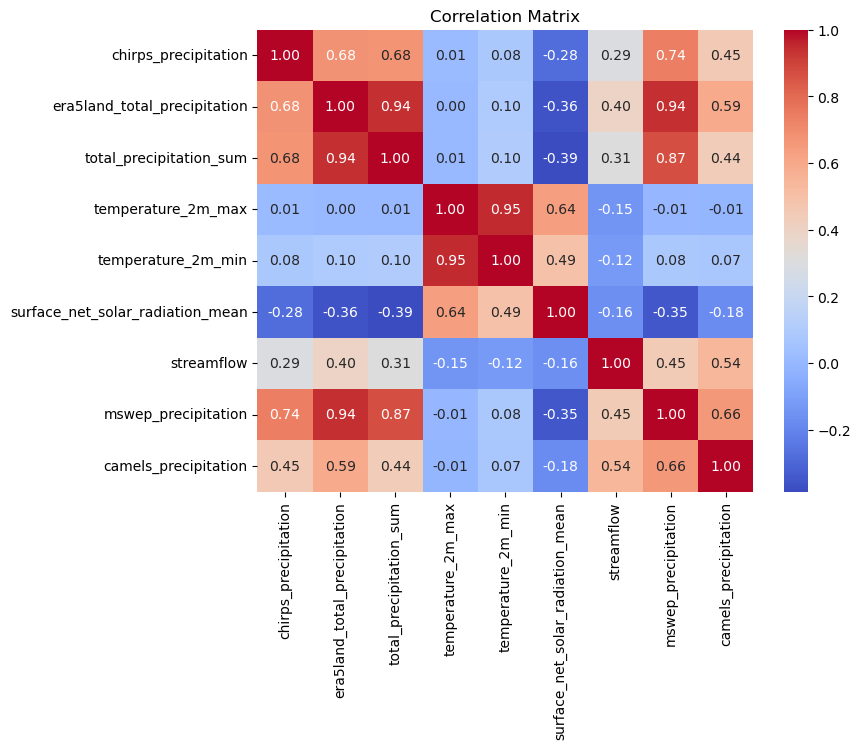

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

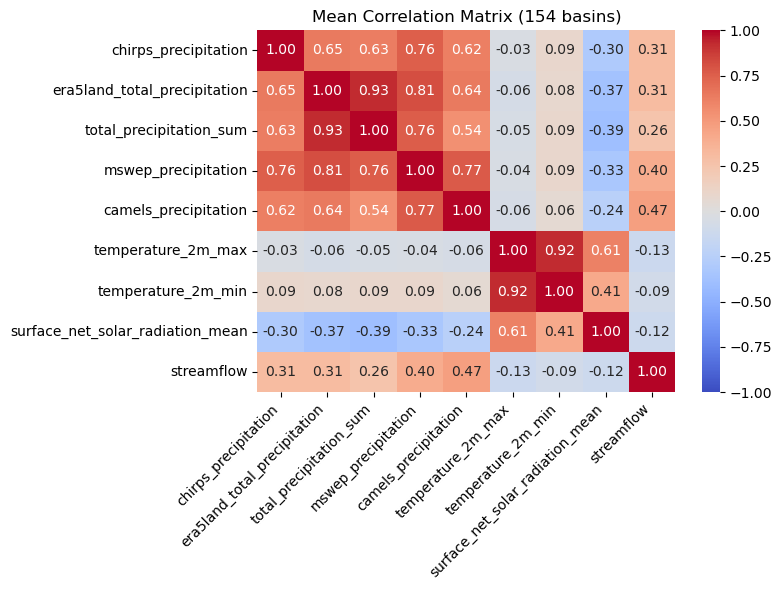

In [12]:
import numpy as np

corr_matrices = []

for basin_name in basins:
    basin_id = basin_name.replace("camels_", "")
    
    try:
        # Load xarray dataset
        ds = xr.open_dataset(time_series / f"{basin_name}.nc")
        ds = ds.drop_vars("basin")
        df = ds.to_dataframe()

        # Load CAMELS txt precipitation
        file_path = next(camels_timeseries.rglob(f"*{basin_id}*.txt"))
        camels = pd.read_csv(file_path, sep="\s+", skiprows=3)
        camels["date"] = pd.to_datetime(camels[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}))
        camels_prcp = camels.set_index("date")[["prcp(mm/day)"]]

        # Join and rename
        df = df.join(camels_prcp, how="left")
        df = df.rename(columns={"prcp(mm/day)": "camels_precipitation"})

        # Round precip cols
        precip_cols = [col for col in df.columns if "precip" in col.lower()]
        df[precip_cols] = df[precip_cols].round(2)

        # Compute correlation and store
        corr_matrices.append(df.corr())

    except Exception as e:
        print(f"Skipping {basin_id}: {e}")

# Stack and compute mean
mean_corr = pd.concat(corr_matrices).groupby(level=0).mean()

# Define your desired order
col_order = [
    "chirps_precipitation",
    "era5land_total_precipitation", 
    "total_precipitation_sum",
    "mswep_precipitation",
    "camels_precipitation",
    "temperature_2m_max",
    "temperature_2m_min",
    "surface_net_solar_radiation_mean",
    "streamflow"
]

# Reorder the mean correlation matrix
mean_corr_ordered = mean_corr.loc[col_order, col_order]

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(mean_corr_ordered, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(rotation=45, ha='right')
plt.title("Mean Correlation Matrix (154 basins)")
plt.tight_layout()
plt.show()

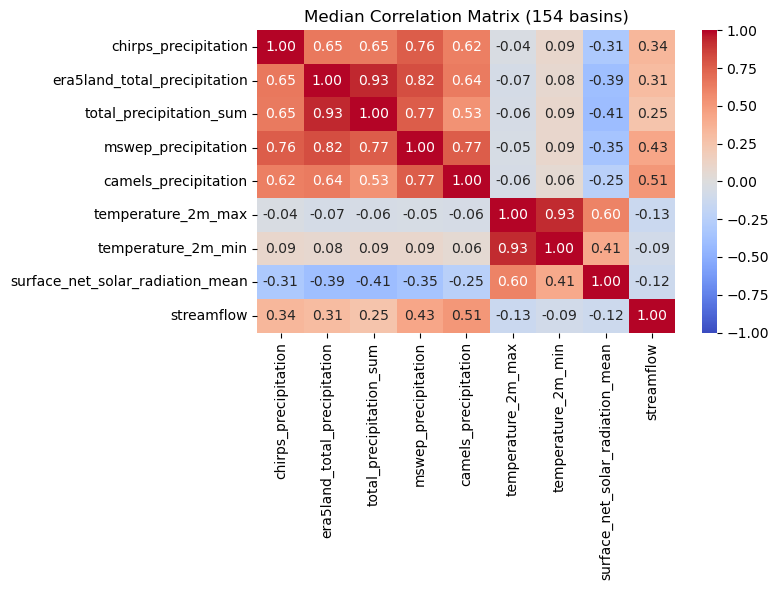

In [13]:
import numpy as np

corr_matrices = []

for basin_name in basins:
    basin_id = basin_name.replace("camels_", "")
    
    try:
        # Load xarray dataset
        ds = xr.open_dataset(time_series / f"{basin_name}.nc")
        ds = ds.drop_vars("basin")
        df = ds.to_dataframe()

        # Load CAMELS txt precipitation
        file_path = next(camels_timeseries.rglob(f"*{basin_id}*.txt"))
        camels = pd.read_csv(file_path, sep="\s+", skiprows=3)
        camels["date"] = pd.to_datetime(camels[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}))
        camels_prcp = camels.set_index("date")[["prcp(mm/day)"]]

        # Join and rename
        df = df.join(camels_prcp, how="left")
        df = df.rename(columns={"prcp(mm/day)": "camels_precipitation"})

        # Round precip cols
        precip_cols = [col for col in df.columns if "precip" in col.lower()]
        df[precip_cols] = df[precip_cols].round(2)

        # Compute correlation and store
        corr_matrices.append(df.corr())

    except Exception as e:
        print(f"Skipping {basin_id}: {e}")

# Stack and compute mean
median_corr = pd.concat(corr_matrices).groupby(level=0).median()

# Define your desired order
col_order = [
    "chirps_precipitation",
    "era5land_total_precipitation", 
    "total_precipitation_sum",
    "mswep_precipitation",
    "camels_precipitation",
    "temperature_2m_max",
    "temperature_2m_min",
    "surface_net_solar_radiation_mean",
    "streamflow"
]

# Reorder the mean correlation matrix
median_corr_ordered = median_corr.loc[col_order, col_order]

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(median_corr_ordered, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Median Correlation Matrix (154 basins)")
plt.tight_layout()
plt.show()

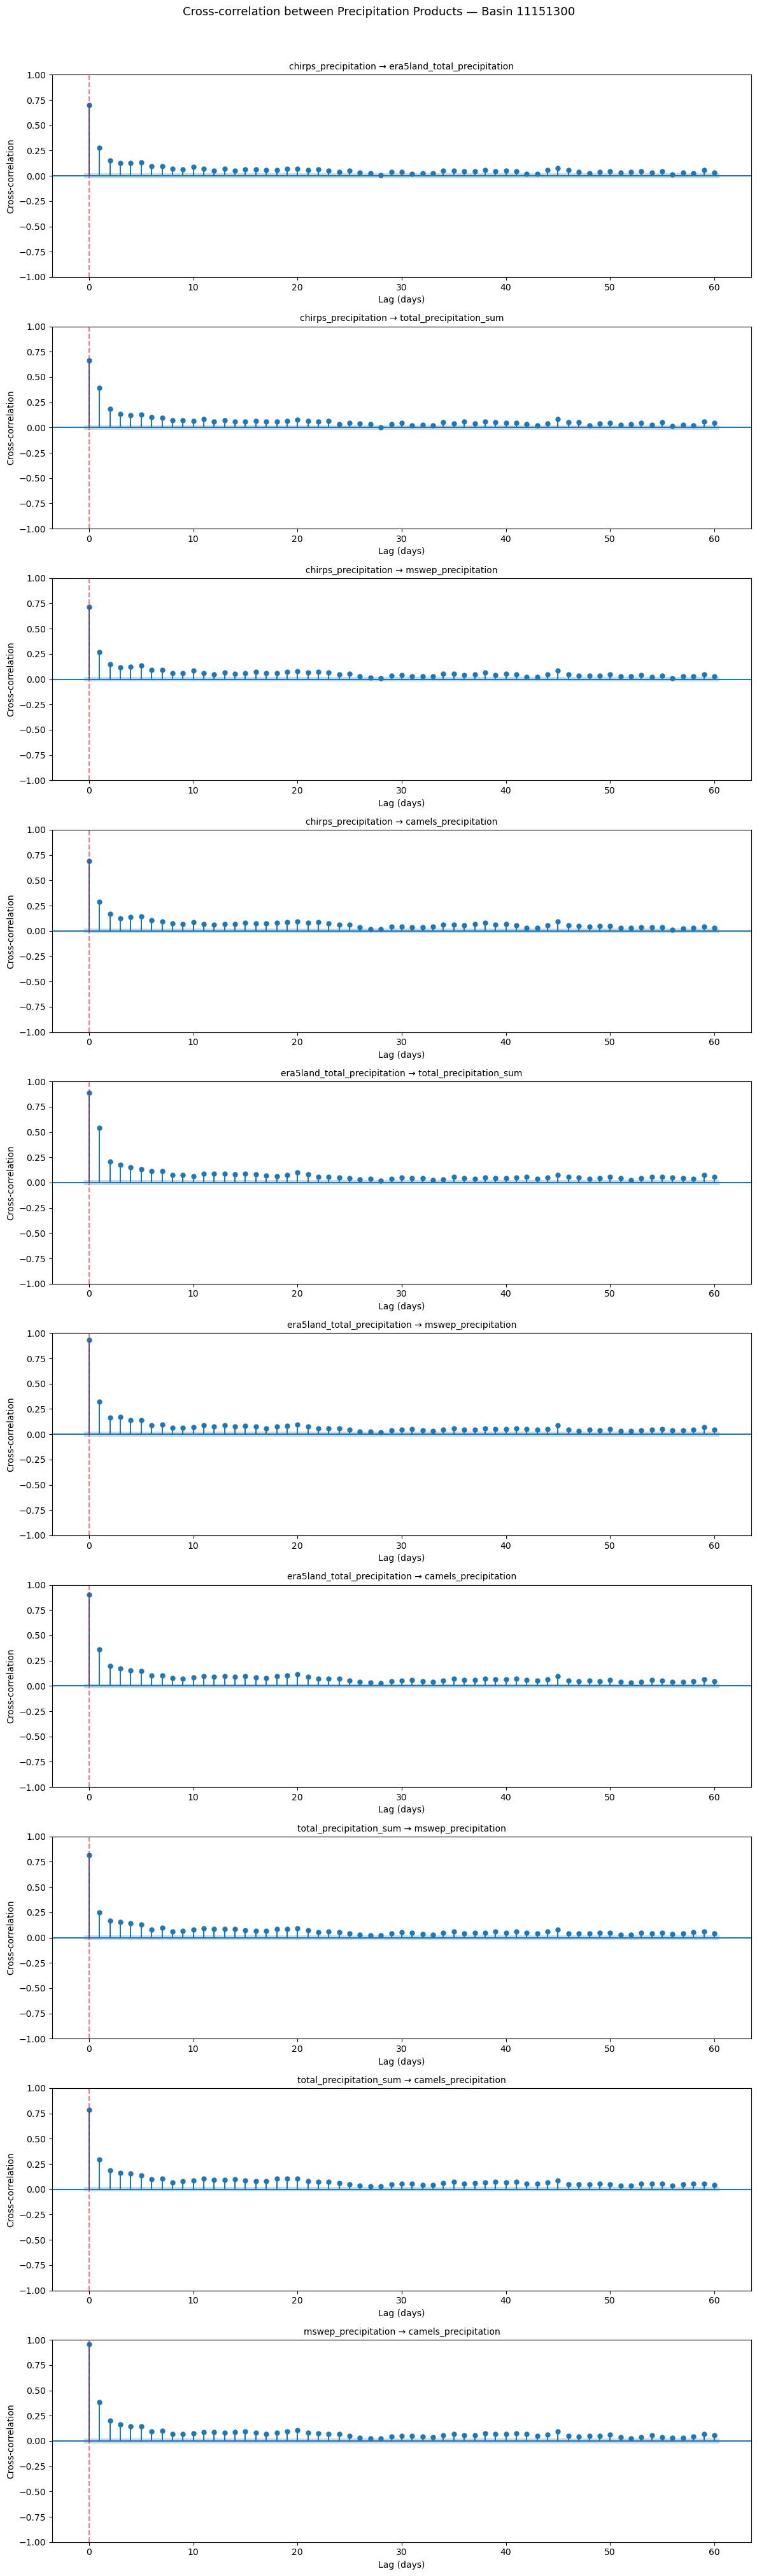

In [14]:
from itertools import combinations
from statsmodels.graphics.tsaplots import plot_ccf

# All pairs of precipitation products
pairs = list(combinations(precip_cols, 2))

fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 4 * len(pairs)))

for ax, (col1, col2) in zip(axes, pairs):
    valid = df[[col1, col2]].dropna()
    plot_ccf(valid[col1], valid[col2], lags=60, ax=ax, alpha=0.05)
    ax.set_title(f"{col1} → {col2}", fontsize=10)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Cross-correlation")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)  # marks lag 0

plt.suptitle(f"Cross-correlation between Precipitation Products — Basin {basin_id}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


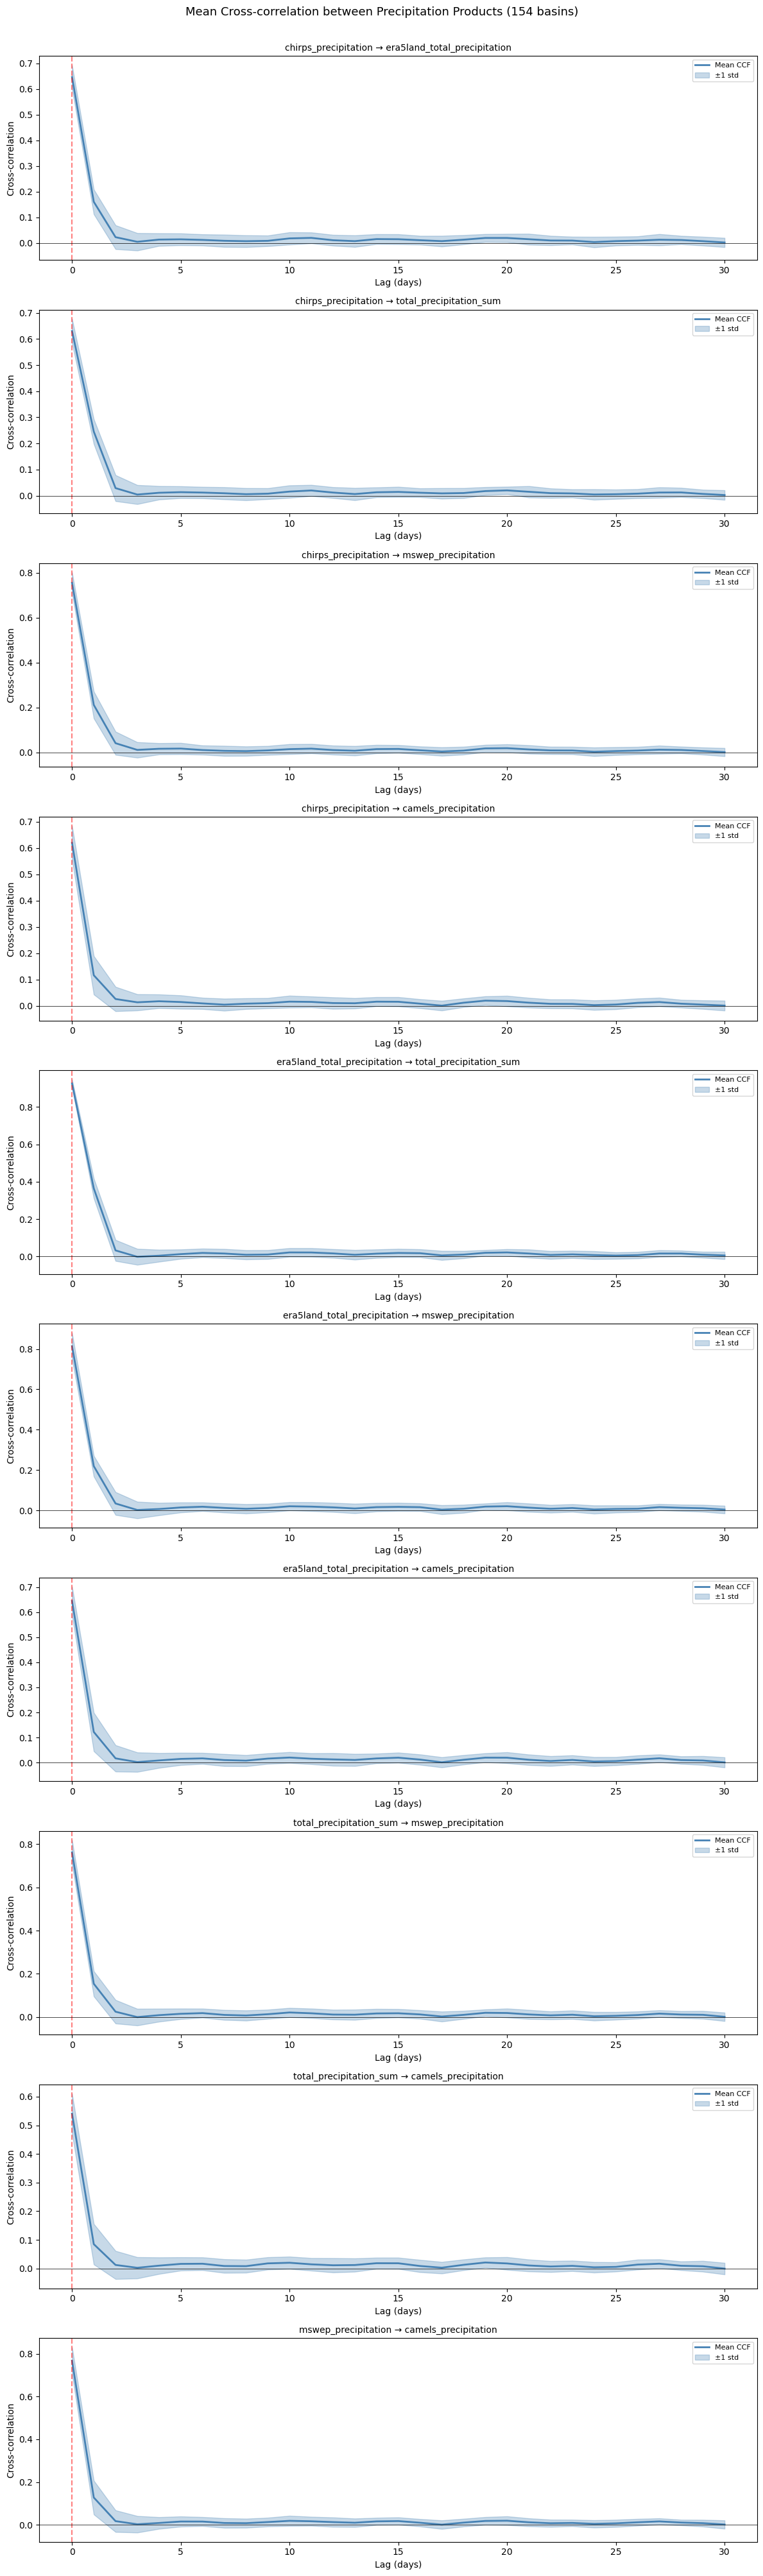

In [15]:
from itertools import combinations
import numpy as np

pairs = list(combinations(precip_cols, 2))
lags = 30

# Store ccf values per pair per basin
# Structure: {(col1, col2): array of shape (n_basins, n_lags)}
ccf_results = {pair: [] for pair in pairs}

for basin_name in basins:
    basin_id = basin_name.replace("camels_", "")
    
    try:
        ds = xr.open_dataset(time_series / f"{basin_name}.nc")
        ds = ds.drop_vars("basin")
        df = ds.to_dataframe()

        file_path = next(camels_timeseries.rglob(f"*{basin_id}*.txt"))
        camels = pd.read_csv(file_path, sep="\s+", skiprows=3)
        camels["date"] = pd.to_datetime(camels[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}))
        camels_prcp = camels.set_index("date")[["prcp(mm/day)"]]
        df = df.join(camels_prcp, how="left")
        df = df.rename(columns={"prcp(mm/day)": "camels_precipitation"})

        for (col1, col2) in pairs:
            valid = df[[col1, col2]].dropna()
            # Manually compute ccf values at each lag
            ccf_vals = [valid[col1].corr(valid[col2].shift(lag)) for lag in range(lags + 1)]
            ccf_results[(col1, col2)].append(ccf_vals)

    except Exception as e:
        print(f"Skipping {basin_id}: {e}")

# Plot
fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 4 * len(pairs)))

for ax, (col1, col2) in zip(axes, pairs):
    data = np.array(ccf_results[(col1, col2)])  # shape: (n_basins, n_lags)
    mean_ccf = data.mean(axis=0)
    std_ccf = data.std(axis=0)
    lag_range = np.arange(lags + 1)

    ax.plot(lag_range, mean_ccf, color="steelblue", linewidth=2, label="Mean CCF")
    ax.fill_between(lag_range, mean_ccf - std_ccf, mean_ccf + std_ccf, 
                    alpha=0.3, color="steelblue", label="±1 std")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_title(f"{col1} → {col2}", fontsize=10)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Cross-correlation")
    ax.legend(fontsize=8)

plt.suptitle("Mean Cross-correlation between Precipitation Products (154 basins)", fontsize=13, y=1.0025)
plt.tight_layout()
plt.show()

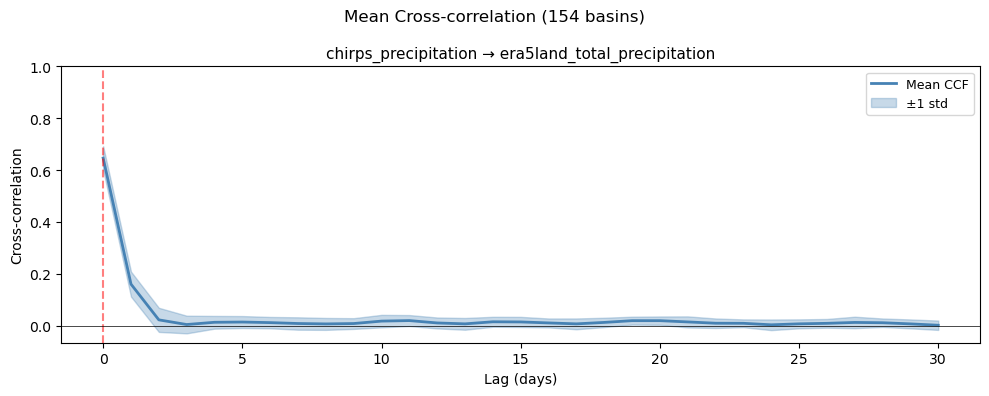

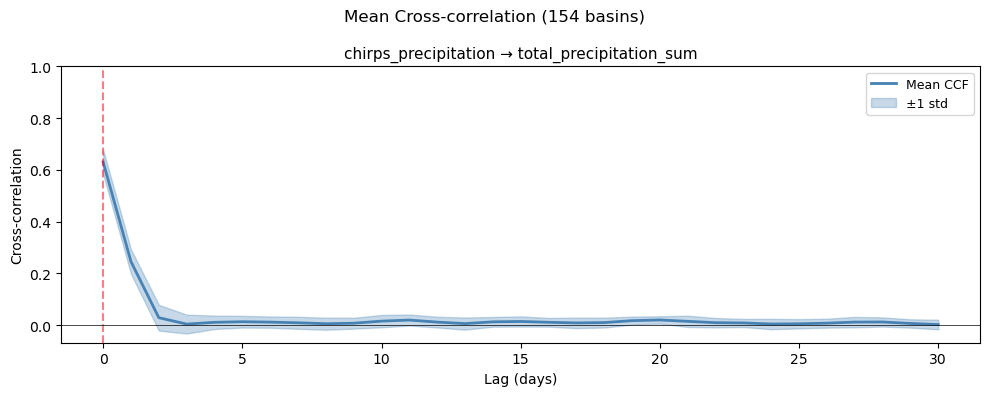

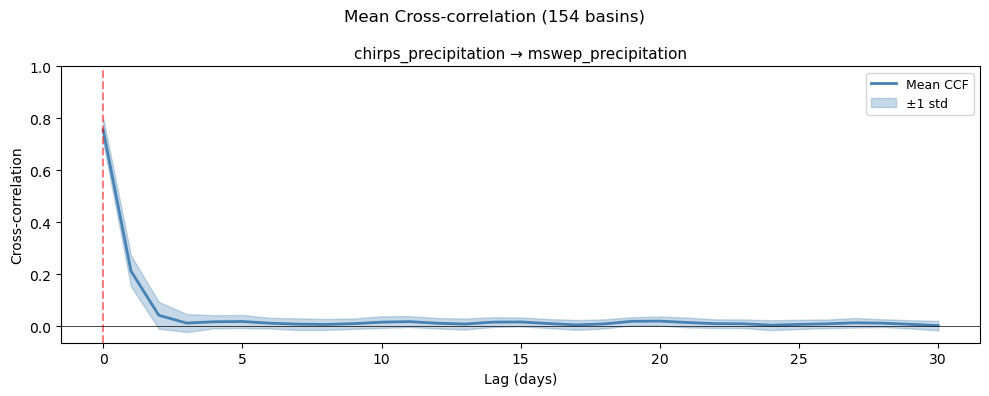

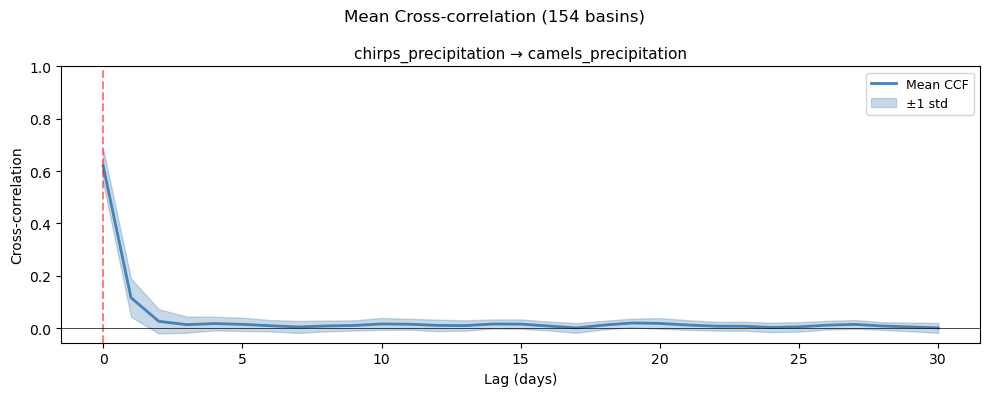

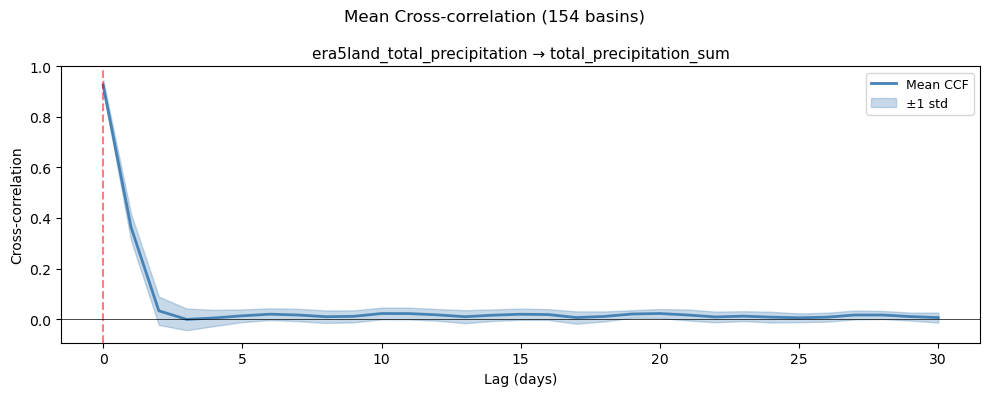

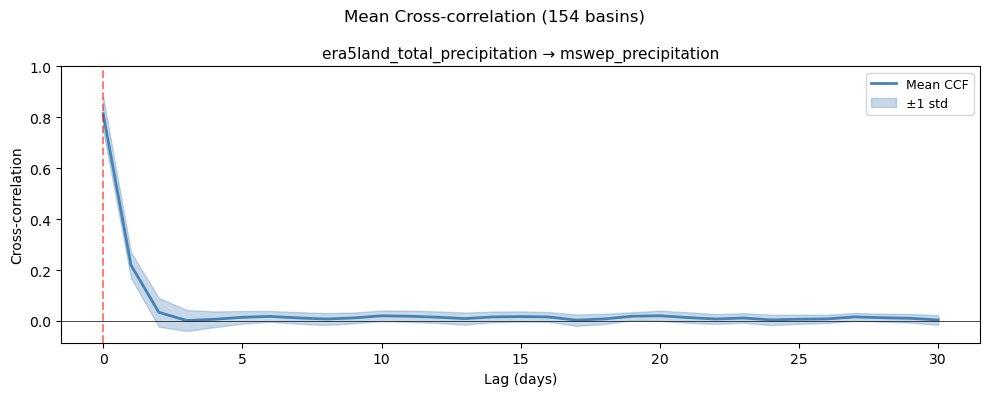

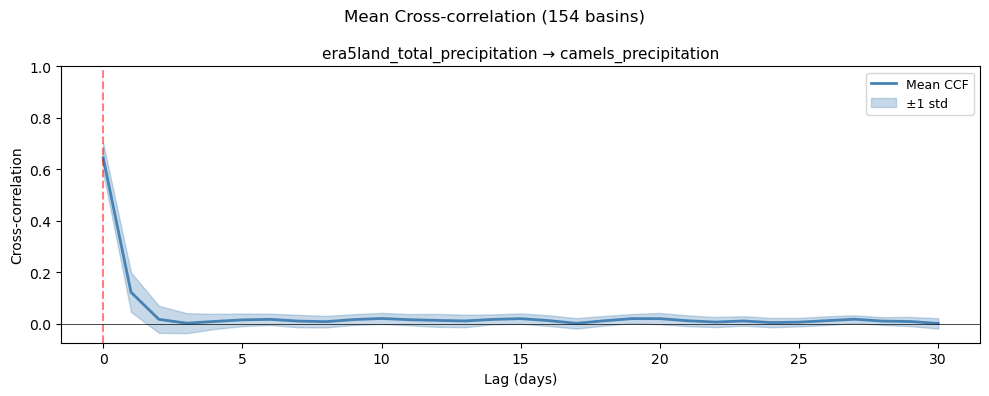

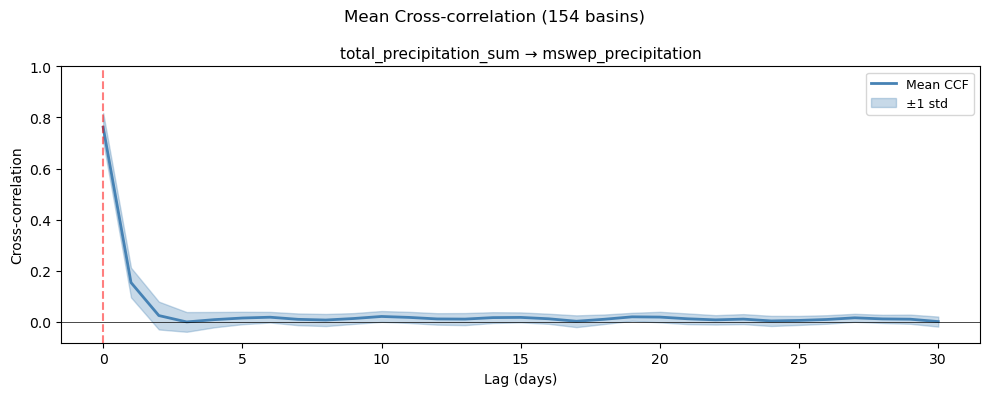

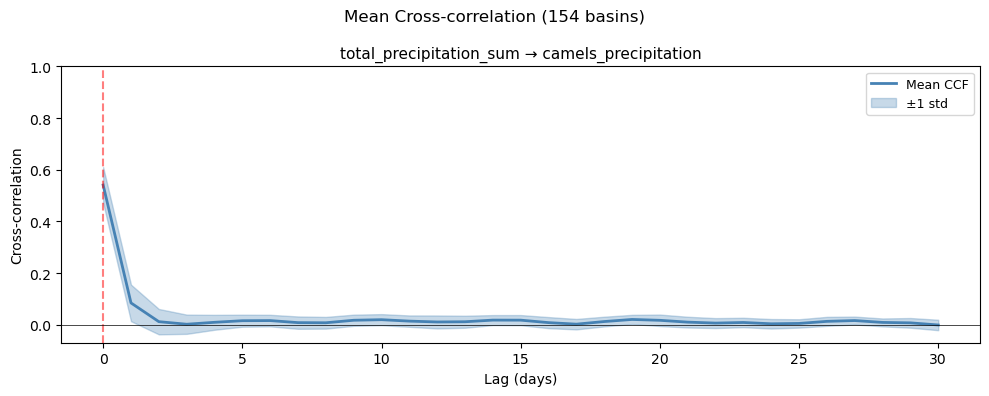

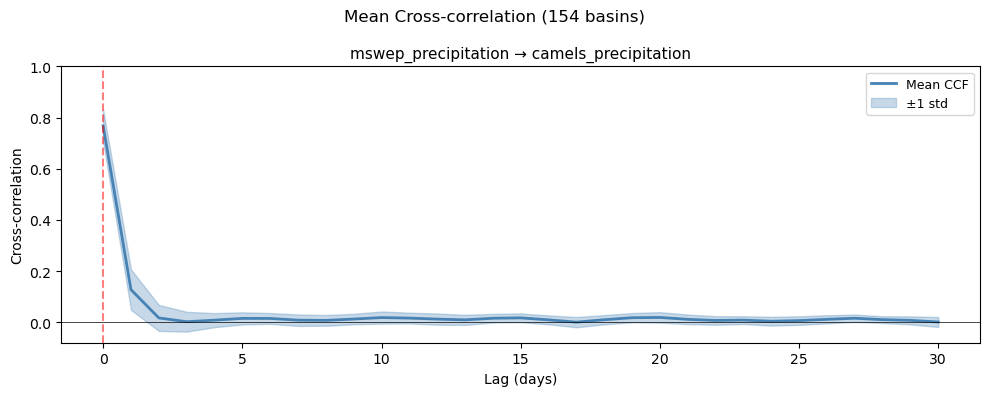

In [16]:
pairs = list(combinations(precip_cols, 2))
lags = 30

ccf_results = {pair: [] for pair in pairs}

for basin_name in basins:
    basin_id = basin_name.replace("camels_", "")
    
    try:
        ds = xr.open_dataset(time_series / f"{basin_name}.nc")
        ds = ds.drop_vars("basin")
        df = ds.to_dataframe()

        file_path = next(camels_timeseries.rglob(f"*{basin_id}*.txt"))
        camels = pd.read_csv(file_path, sep="\s+", skiprows=3)
        camels["date"] = pd.to_datetime(camels[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}))
        camels_prcp = camels.set_index("date")[["prcp(mm/day)"]]
        df = df.join(camels_prcp, how="left")
        df = df.rename(columns={"prcp(mm/day)": "camels_precipitation"})

        for (col1, col2) in pairs:
            valid = df[[col1, col2]].dropna()
            ccf_vals = [valid[col1].corr(valid[col2].shift(lag)) for lag in range(lags + 1)]
            ccf_results[(col1, col2)].append(ccf_vals)

    except Exception as e:
        print(f"Skipping {basin_id}: {e}")

# One figure per pair
for (col1, col2) in pairs:
    fig, ax = plt.subplots(figsize=(10, 4))

    data = np.array(ccf_results[(col1, col2)])
    mean_ccf = data.mean(axis=0)
    std_ccf = data.std(axis=0)
    lag_range = np.arange(lags + 1)

    ax.plot(lag_range, mean_ccf, color="steelblue", linewidth=2, label="Mean CCF")
    ax.fill_between(lag_range, mean_ccf - std_ccf, mean_ccf + std_ccf,
                    alpha=0.3, color="steelblue", label="±1 std")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_title(f"{col1} → {col2}", fontsize=11)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Cross-correlation")
    ax.legend(fontsize=9)
    ax.set_ylim(top=1)

    plt.suptitle("Mean Cross-correlation (154 basins)", fontsize=12)
    plt.tight_layout()
    plt.show()

# For UY basins

In [17]:
with open(basins_file_uy, "r") as f:
    basins_uy = f.read().splitlines()

basins_uy

['CAMELS_UY_2',
 'CAMELS_UY_3',
 'CAMELS_UY_5',
 'CAMELS_UY_6',
 'CAMELS_UY_7',
 'CAMELS_UY_8',
 'CAMELS_UY_9',
 'CAMELS_UY_10',
 'CAMELS_UY_11',
 'CAMELS_UY_15',
 'CAMELS_UY_16']

In [19]:
ds_uy = xr.open_dataset(time_series_uy / "CAMELS_UY_6.nc")
ds_uy


<xarray.Dataset> Size: 498kB
Dimensions:             (date: 11322)
Coordinates:
  * date                (date) datetime64[ns] 91kB 1989-01-01 ... 2019-12-31
Data variables:
    tmin_C              (date) float32 45kB ...
    tmax_C              (date) float32 45kB ...
    srad_W_m2           (date) float32 45kB ...
    prcp_mm_day         (date) float32 45kB ...
    QObs_mm_d           (date) float64 91kB ...
    prcp_gauge_mm_day   (date) float32 45kB ...
    prcp_mswep_mm_day   (date) float32 45kB ...
    prcp_chirps_mm_day  (date) float32 45kB ...
Attributes:
    precip_update:  Gauge, MSWEP and CHIRPS added where available

Available columns: ['tmin_C', 'tmax_C', 'srad_W_m2', 'prcp_mm_day', 'QObs_mm_d', 'prcp_gauge_mm_day', 'prcp_mswep_mm_day', 'prcp_chirps_mm_day']


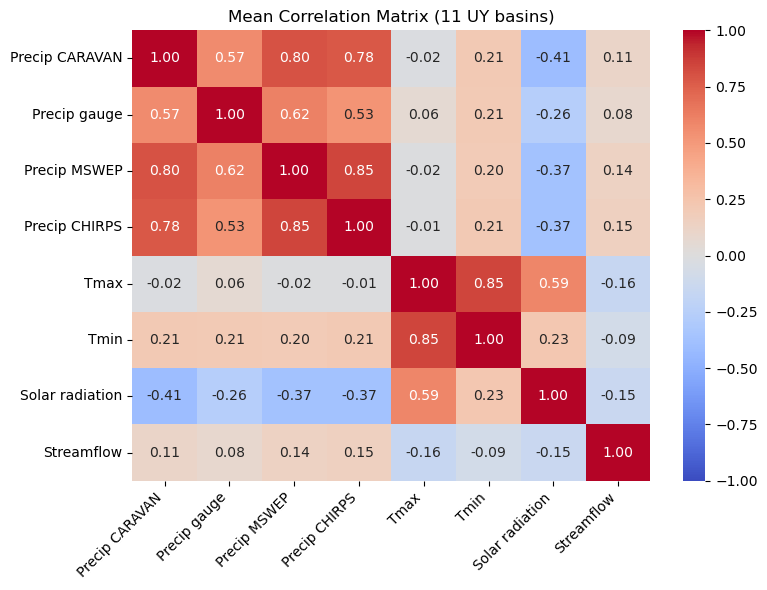

In [22]:
corr_matrices = []

for basin_name in basins_uy:
    try:
        ds = xr.open_dataset(time_series_uy / f"{basin_name}.nc")
        
        # Drop non-numeric coords/vars if present
        vars_to_drop = [v for v in ["basin"] if v in ds]
        if vars_to_drop:
            ds = ds.drop_vars(vars_to_drop)
        
        df = ds.to_dataframe()

        # Round precip cols
        precip_cols = [col for col in df.columns if "prcp" in col.lower() or "precip" in col.lower()]
        df[precip_cols] = df[precip_cols].round(2)

        corr_matrices.append(df.corr(numeric_only=True))

    except Exception as e:
        print(f"Skipping {basin_name}: {e}")

# Stack and compute mean
mean_corr = pd.concat(corr_matrices).groupby(level=0).mean()

print("Available columns:", mean_corr.columns.tolist())

# Column order matching YOUR dataset's variable names
col_order = [
    "prcp_mm_day",          # main precip
    "prcp_gauge_mm_day",    # gauge precip
    "prcp_mswep_mm_day",    # MSWEP precip
    "prcp_chirps_mm_day",   # CHIRPS precip
    "tmax_C",
    "tmin_C",
    "srad_W_m2",
    "QObs_mm_d",            # streamflow
]

# Only keep cols that actually exist
col_order = [c for c in col_order if c in mean_corr.columns]

mean_corr_ordered = mean_corr.loc[col_order, col_order]

# Nicer display labels
label_map = {
    "prcp_mm_day":          "Precip CARAVAN",
    "prcp_gauge_mm_day":    "Precip gauge",
    "prcp_mswep_mm_day":    "Precip MSWEP",
    "prcp_chirps_mm_day":   "Precip CHIRPS",
    "tmax_C":               "Tmax",
    "tmin_C":               "Tmin",
    "srad_W_m2":            "Solar radiation",
    "QObs_mm_d":            "Streamflow",
}
mean_corr_ordered = mean_corr_ordered.rename(
    index=label_map, columns=label_map
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    mean_corr_ordered,
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Mean Correlation Matrix (11 UY basins)")
plt.tight_layout()
plt.show()